In [2]:
#!pip install selectivesearch

In [ ]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import selectivesearch
import numpy as np
import cv2
import json

In [29]:
dataset_path = '../sg_dataset'

test_graph_path = dataset_path + '/sg_test_annotations.json'
train_graph_path = dataset_path + '/sg_train_annotations.json'
test_images_path = dataset_path + '/sg_test_images/'
train_images_path = dataset_path + '/sg_train_images/'

In [60]:
# load images with PIL

def load_images_pil(train_images_path):
    images = {}
    for filename in os.listdir(train_images_path):
        if filename.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(train_images_path, filename)
            img = Image.open(img_path)  # ensure 3 channels
            images[filename] = img
    return images

In [61]:
# load images using PIL
images = load_images_pil(train_images_path)
len(images)

3999

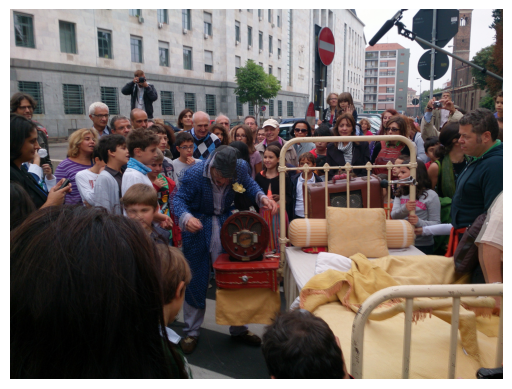

In [89]:
# display first image
#index = np.random.randint(0, len(images))
imgage_test = images[list(images.keys())[0]]
plt.imshow(imgage_test)
plt.axis("off")
plt.show()


In [90]:
def get_selective_search_regions(img):
    img = np.array(img)
    _, regions = selectivesearch.selective_search(img, scale=500, sigma=0.9, min_size=10)
    return regions

In [93]:
# Display the first 10 region proposals
regions = get_selective_search_regions(imgage_test)
region_test = regions
region_test


d:\Paris Cité\MVA\RR\.venv\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


[{'rect': (0, 0, 15, 16), 'size': 61, 'labels': [np.float64(0.0)]},
 {'rect': (0, 0, 180, 118), 'size': 12540, 'labels': [np.float64(1.0)]},
 {'rect': (172, 0, 1, 11), 'size': 12, 'labels': [np.float64(2.0)]},
 {'rect': (173, 0, 276, 148), 'size': 24288, 'labels': [np.float64(3.0)]},
 {'rect': (197, 0, 14, 3), 'size': 44, 'labels': [np.float64(4.0)]},
 {'rect': (246, 0, 16, 15), 'size': 249, 'labels': [np.float64(5.0)]},
 {'rect': (251, 0, 27, 35), 'size': 519, 'labels': [np.float64(6.0)]},
 {'rect': (293, 0, 25, 44), 'size': 568, 'labels': [np.float64(7.0)]},
 {'rect': (318, 0, 0, 15), 'size': 16, 'labels': [np.float64(8.0)]},
 {'rect': (318, 0, 7, 30), 'size': 220, 'labels': [np.float64(9.0)]},
 {'rect': (319, 0, 12, 34), 'size': 164, 'labels': [np.float64(10.0)]},
 {'rect': (356, 0, 0, 11), 'size': 12, 'labels': [np.float64(11.0)]},
 {'rect': (356, 0, 12, 55), 'size': 630, 'labels': [np.float64(12.0)]},
 {'rect': (368, 0, 0, 41), 'size': 42, 'labels': [np.float64(13.0)]},
 {'rect': 

In [94]:
# Number of regions extracted
len(region_test)

2009

In [95]:
# plot the regions on the image using cv2

def draw_boxes_cv(img_np, boxes, color=(0, 0, 255), thickness=2):
    """
    img_np: NumPy array (H, W, C)
    boxes: list of (x, y, w, h)
    """
    img = img_np.copy()
    img = np.array(img)

    for x, y, w, h in boxes:
        cv2.rectangle(
            img,
            (x, y),
            (x + w, y + h),
            color,
            thickness
        )
    return img


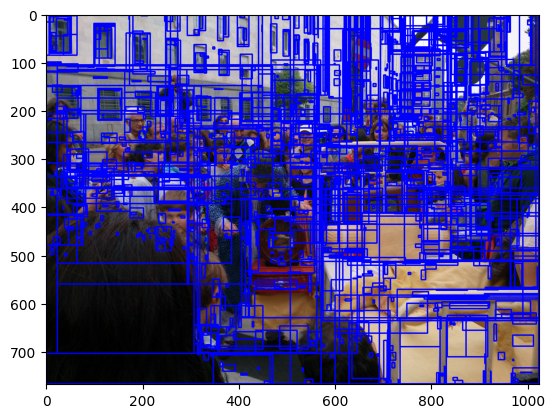

In [96]:
img = draw_boxes_cv(imgage_test, [region['rect'] for region in region_test])
plt.imshow(img)

In [97]:
def get_selective_search_boxes(
    img,
    scale=700,
    sigma=0.8,
    min_size=20,
    min_area=300,
    max_area_ratio=0.6,
    max_aspect_ratio=3.0
):
    """
    Returns filtered Selective Search bounding boxes.

    Output format:
        List of (x, y, w, h)
    """

    # 1. Ensure NumPy RGB image
    img = np.array(img)
    H, W, _ = img.shape
    img_area = H * W

    # 2. Run Selective Search
    _, regions = selectivesearch.selective_search(
        img,
        scale=scale,
        sigma=sigma,
        min_size=min_size
    )

    boxes = set()

    # 3. Filter regions aggressively
    for r in regions:
        x, y, w, h = r["rect"]
        area = w * h

        # too small
        if area < min_area:
            continue

        # too large (almost whole image)
        if area > max_area_ratio * img_area:
            continue

        # bad aspect ratios (very long / flat boxes)
        aspect_ratio = max(w / h, h / w)
        if aspect_ratio > max_aspect_ratio:
            continue

        boxes.add((x, y, w, h))

    return list(boxes)


In [98]:
boxes = get_selective_search_boxes(imgage_test)

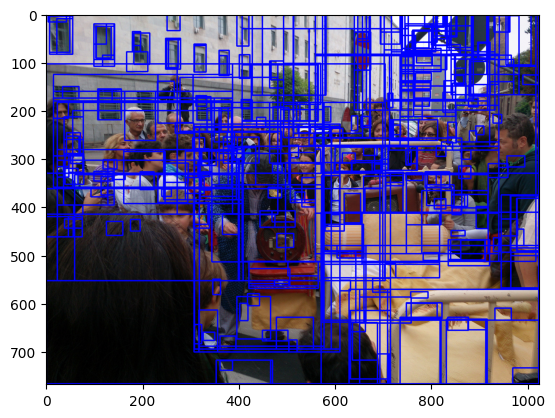

In [102]:
img = draw_boxes_cv(imgage_test, boxes)
plt.imshow(img)

In [103]:
len(boxes)

410

In [104]:
# Save the bouding box list for each train image
boxes_per_image = {}
for image_name, image in images.items():
    boxes = get_selective_search_boxes(image)
    boxes_per_image[image_name] = boxes


d:\Paris Cité\MVA\RR\.venv\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# Save the bowes as a json file
with open('selective_search_boxes_train.json', 'w') as f:
    json.dump(boxes_per_image, f)